# Proyecto de Machine Learning - Análisis y Clasificación

Este notebook contiene el flujo principal de análisis y desarrollo del modelo de machine learning.

Este proyecto trata sobre los habitos de compra de 400 personas mayores de edad, con salario, genero y variable objetivo de:
- 0 - No Compró
- 1 - Si Compró

## Estructura del Proyecto
- `data/` - Datos del proyecto
- `notebooks/` - Jupyter Notebooks
- `models/` - Modelos entrenados
- `src/` - Código fuente reutilizable
- `requirements.txt` - Dependencias del proyecto

In [ ]:
# Importar librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

##  Paso 1: Preparación de datos

1. Carga de datos y crear dataset
1. Identificar forma del dataset
1. Identificar valores duplicados


In [31]:
# Cargar datos
df = pd.read_csv('../data/user+data.csv')
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [32]:
# Mostrar información básica
print("Forma del dataset:", df.shape)
print("\nInformación del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe().round(2))

Forma del dataset: (400, 5)

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB
None

Estadísticas descriptivas:
           User ID     Age  EstimatedSalary  Purchased
count       400.00  400.00           400.00     400.00
mean   15691539.76   37.66         69742.50       0.36
std       71658.32   10.48         34096.96       0.48
min    15566689.00   18.00         15000.00       0.00
25%    15626763.75   29.75         43000.00       0.00
50%    15694341.50   37.00         70000.00       0.00
75%    15750363.00   46.00         88000.00       1.00
max    15815236.00   60.0

## Paso 2:  Exploración de Datos

1. Análisis exploratorio del dataset
1. Identificar valores faltantes
1. Estadistica descrptiva
1. Visualizaciones
1. Correlaciones

In [33]:
# Verificar valores faltantes
print("Valores faltantes:")
print(df.isnull().sum())

Valores faltantes:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


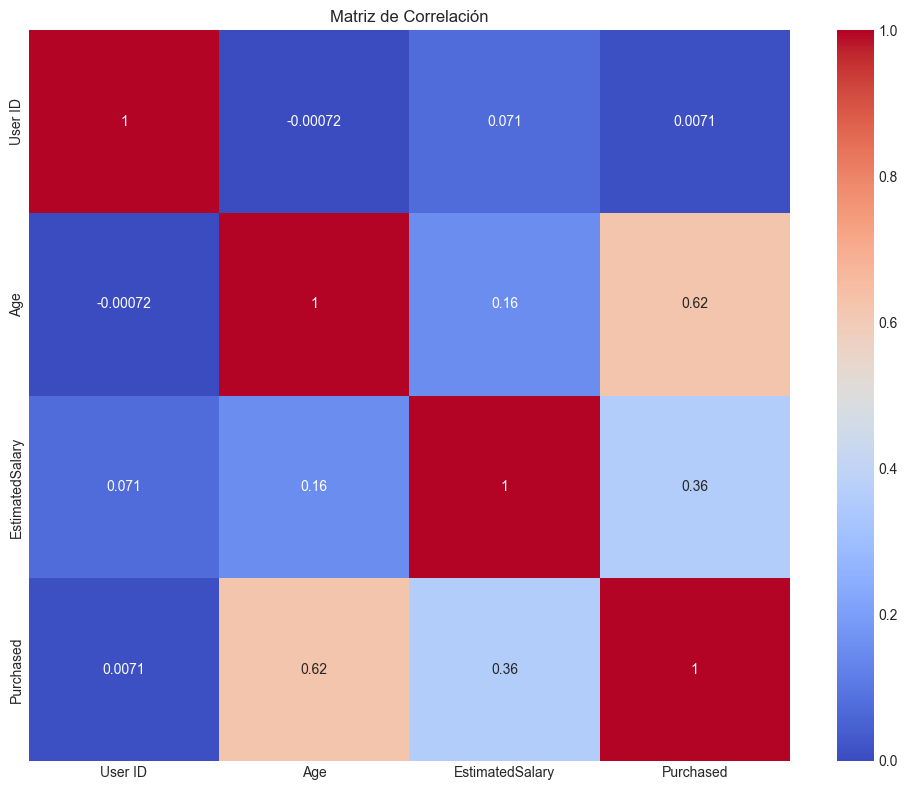

In [36]:
# Excluyeme del dataset Gender
df1 = df.drop(columns=['Gender'])

# Visualizar correlaciones (si el dataset tiene solo columnas numéricas) 
if df.select_dtypes(include=[np.number]).shape[1] > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')
    plt.title('Matriz de Correlación')
    plt.tight_layout()
    plt.show()

### 1.2 Visualizaciones

Gráficos exploratorios del dataset

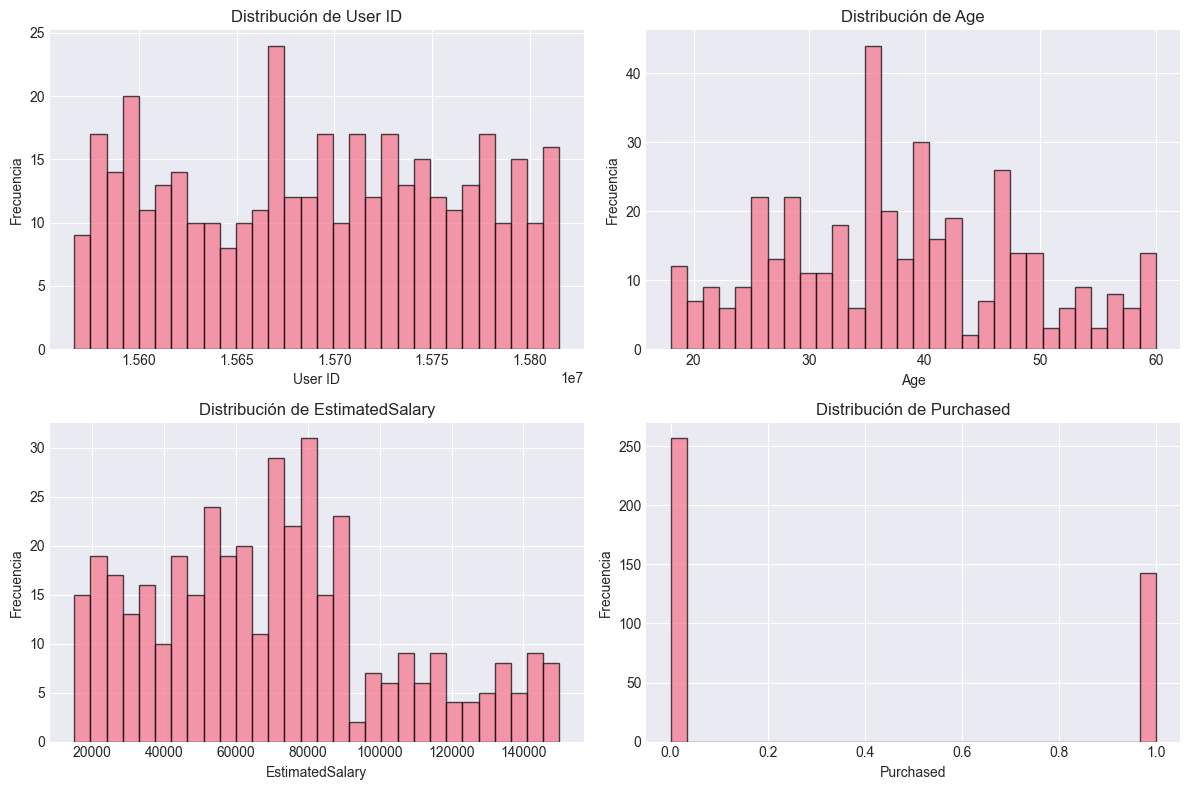

In [37]:
# Distribución de columnas numéricas
numeric_cols = df1.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:4]):
    axes[idx].hist(df1[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## Paso 3: Ingenieria de caracteristicas ( Feature Engineering)

1. Codificar variables categoricas
1. Nuevas caracteristicas si es necesario
1. Eliminar caracteristicas o atributos irrelevantes
1. Opcional: Estandarizar o Normalizar los datos

In [35]:

# Convertir gender male = 0 y female = 1 con lista de comprensión
df['Gender'] = [0 if g == 'male' else 1 for g in df['Gender']]

# Ver valores de gender
df.head(5)



,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,1,19,76000,0


## Paso 4: Dividir conjutno de datos

1. Separar el conjunto de entrenamiento (70-80%) y de prueba  (20-30%)

In [38]:
# Identificar las columnas
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')

In [39]:
# Definir X e y

X = df[['User ID', 'Gender', 'Age', 'EstimatedSalary']]
y = df['Purchased'] 

In [43]:
# Exploremos la forma de nuestras variables X e y
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (400, 4)
Forma de y: (400,)


In [41]:
# convertir a numpy arrays
X = X.values
y = y.values

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 42)

In [54]:
# Prueba: verificar shape del conjunto de entrenamiento y prueba
print("Cantidad de registros X_train:", X_train.shape[0])  
print("Cantidad de registros y_train:", y_train.shape[0]) 
print("Cantidad de registros X_test:", X_test.shape[0])
print("Cantidad de registros y_test:", y_test.shape[0])

Cantidad de registros X_train: 300
Cantidad de registros y_train: 300
Cantidad de registros X_test: 100
Cantidad de registros y_test: 100


In [55]:
# Ver el head del x_train
print("Primeros 5 registros de X_train:")
print(X_train[:5])

Primeros 5 registros de X_train:
[[15775590        1       57   122000]
 [15665416        1       39    71000]
 [15733883        1       47    25000]
 [15679760        1       24    19000]
 [15619087        1       36    50000]]


## Paso 5: Entrenar el modelo

1. Aplicar estandarizacion (StandarScaler) o normalizacion de valores
1. Algoritmos sensible a la magnitud o distancias ( KNN, Regresion Logistica)
1. Seleccionar el modelo


In [60]:
from sklearn.preprocessing import StandardScaler

# Estandarizar el conjunto de entrenamiento

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [61]:
# Visualizar los primeros 5 registros de X_train escalado
print("Primeros 5 registros de X_train escalado:")
print(X_train_scaled[:5])

Primeros 5 registros de X_train escalado:
[[ 1.19633572  0.          1.8925893   1.52189404]
 [-0.32346821  0.          0.1250379   0.03213212]
 [ 0.62100522  0.          0.9106163  -1.31157471]
 [-0.12559877  0.         -1.34792161 -1.48684082]
 [-0.96255725  0.         -0.169554   -0.58129926]]


In [62]:
# Seleccionar el modelo en este caso KNN
from sklearn.neighbors import KNeighborsClassifier

modelo_clasificacion = KNeighborsClassifier(n_neighbors = 5, metric='minkowski')

# Entrenar el modelo con el conjunto de entrenamiento escalado
modelo_clasificacion.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# Realizar algunas predicciones con el conjunto de prueba escalado
X_test_scaled = scaler.transform(X_test)

y_pred = modelo_clasificacion.predict(X_test_scaled)
print("Predicciones con escalar X_test:")
print(y_pred)

Predicciones con escalar X_test:
[1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0
 1 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 0 0 0 1 0 1 1]


In [67]:
# Podemos construir un dataset con los valores reales y las predicciones para comparar
resultados = pd.DataFrame({'Real': y_test, 'Predicción': y_pred})
print("Comparación entre valores reales y predicciones:")
resultados

Comparación entre valores reales y predicciones:


,Real,Predicción
0,0,1
1,1,1
2,0,0
3,1,1
4,0,0
...,...,...
95,0,0
96,1,1
97,0,0
98,1,1


construir la matriz de confusión

In [ ]:
# Importando la libreria para la matriz de confusión y el reporte de clasificación
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

# Construir dataframe para la matriz de confusión
cm_df = pd.DataFrame(cm, index=['Real Negativo', 'Real Positivo'], columns=['Predicho Negativo', 'Predicho Positivo'])
print("Matriz de confusión:")
print(cm_df)


# Construir printar el reporte de clasificación
report_dict = classification_report(y_test, y_pred, output_dict=True)
negativo = report_dict['0']
positivo = report_dict['1']

print("\nReporte de clasificación:")
print(f"Reporte negativa (0):\n{negativo}\n")
print(f"Reporte positiva (1):\n{positivo}\n")

Matriz de confusión:
               Predicho Negativo  Predicho Positivo
Real Negativo                 60                  3
Real Positivo                  2                 35

Reporte de clasificación:
Reporte negativa (0):
{'precision': 0.967741935483871, 'recall': 0.9523809523809523, 'f1-score': 0.96, 'support': 63.0}

Reporte positiva (1):
{'precision': 0.9210526315789473, 'recall': 0.9459459459459459, 'f1-score': 0.9333333333333333, 'support': 37.0}



## Paso 6: Realizar predicciones con el modelo entrenado

In [78]:
# Pedir datos al usuario para hacer una predicción personalizada
edad = int(input("Ingrese la edad del usuario: "))
salario = float(input("Ingrese el salario estimado del usuario: "))
genero = input("Ingrese el género del usuario (male/female): ").strip().lower()

# Crear un array con los datos del usuario y hacer la predicción
genero_num = 0 if genero == 'male' else 1
input_data = np.array([[0, genero_num, edad, salario]])  # User ID

input_data_scaled = scaler.transform(input_data)
prediccion_usuario = modelo_clasificacion.predict(input_data_scaled)

# Ahora quiero imprimir los print de la predicción personalizada
print(f"Edad: {edad}, Salario: {salario}, Género: {genero} -> Predicción de compra: {'Sí' if prediccion_usuario[0] == 1 else 'No'}")

Edad: 37, Salario: 70000.0, Género: female -> Predicción de compra: No
